# KHÁM PHÁ CÁC MẪU (PATTERN DISCOVERY) TRONG DỮ LIỆU NĂNG LƯỢNG MẶT TRỜI

Mục tiêu: Tìm ra các khuôn mẫu ẩn giấu trong quá trình phát điện liên quan đến thời gian (giờ, ngày trong tuần, tháng) và các sự kiện (ngày nghỉ lễ). Ghi chú: Các biến `is_semester`, `is_exam` tạm thời bị loại bỏ khỏi phân tích do dữ liệu gốc (DWH) chưa được cập nhật chính xác (100% là No).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import urllib.parse
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 7)

load_dotenv()
db_user = os.getenv("DB_USER")
db_password = urllib.parse.quote_plus(os.getenv("DB_PASSWORD") or "")
db_host = os.getenv("DB_HOST")
db_port = os.getenv("DB_PORT")
db_name = os.getenv("DB_NAME")

engine = create_engine(f"postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}")
print("Đã kết nối Database thành công!")


Đã kết nối Database thành công!


## 1. Tải và Làm sạch dữ liệu

In [2]:
# Kéo dữ liệu từ view và join với dim_date
query = """
    SELECT 
        m.date_id,
        m.hourly_bucket, 
        m.e_hourly as total_energy, 
        d.is_holiday,
        d.month
    FROM bi_mart.mv_bi_mart_hourly_measures m
    JOIN bi_mart.dim_date d ON m.date_id = d.date_id
"""
print("Đang kéo dữ liệu từ Supabase...")
df = pd.read_sql_query(query, engine)

if df.empty:
    print("Không có dữ liệu!")
else:
    # Xử lý kiểu dữ liệu
    df['is_holiday'] = df['is_holiday'].astype(str).str.strip().str.lower()
    df['is_holiday'] = df['is_holiday'].map({'true': 'Yes', 'false': 'No', '1': 'Yes', '0': 'No'}).fillna('Unknown')
    
    # Tạo thêm đặc trưng (Features)
    df['date'] = pd.to_datetime(df['date_id'].astype(str), format='%Y%m%d')
    df['day_of_week'] = df['date'].dt.day_name() # Thứ trong tuần
    df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6]).map({True: 'Yes', False: 'No'})
    
    # Lọc bỏ giá trị rác (âm) hoặc fill null
    df['total_energy'] = df['total_energy'].fillna(0)
    df.loc[df['total_energy'] < 0, 'total_energy'] = 0
    
    print(f"Kéo thành công {len(df)} dòng dữ liệu.")
    display(df.head())


Đang kéo dữ liệu từ Supabase...


Kéo thành công 683385 dòng dữ liệu.


,date_id,hourly_bucket,total_energy,is_holiday,month,date,day_of_week,is_weekend
0,20220423,23,0.0,No,4,2022-04-23,Saturday,Yes
1,20220423,22,0.0,No,4,2022-04-23,Saturday,Yes
2,20220423,21,0.0,No,4,2022-04-23,Saturday,Yes
3,20220423,20,0.0,No,4,2022-04-23,Saturday,Yes
4,20220423,19,0.0,No,4,2022-04-23,Saturday,Yes


## 2. Bảng Tổng hợp và So sánh (Pivot Tables)

In [3]:
# BẢNG TỔNG HỢP (PIVOT TABLES)

# Pattern: Năng lượng trung bình giữa Ngày nghỉ lễ vs Ngày thường
holiday_impact = df.groupby('is_holiday')['total_energy'].agg(['mean', 'median', 'count']).round(2)
print("\nSự ảnh hưởng của Ngày nghỉ lễ (is_holiday):")
display(holiday_impact)

# Pattern: Cuối tuần vs Ngày trong tuần
weekend_impact = df.groupby('is_weekend')['total_energy'].agg(['mean', 'median', 'count']).round(2)
print("\nSự ảnh hưởng của Ngày cuối tuần (is_weekend):")
display(weekend_impact)



Sự ảnh hưởng của Ngày nghỉ lễ (is_holiday):


,mean,median,count
is_holiday,,,
No,13.61,0.24,681201
Yes,19.80,2.58,2184



Sự ảnh hưởng của Ngày cuối tuần (is_weekend):


,mean,median,count
is_weekend,,,
No,13.61,0.24,490666
Yes,13.67,0.25,192719


## 3. Trực quan hóa Mẫu phát điện (Pattern Profiling)

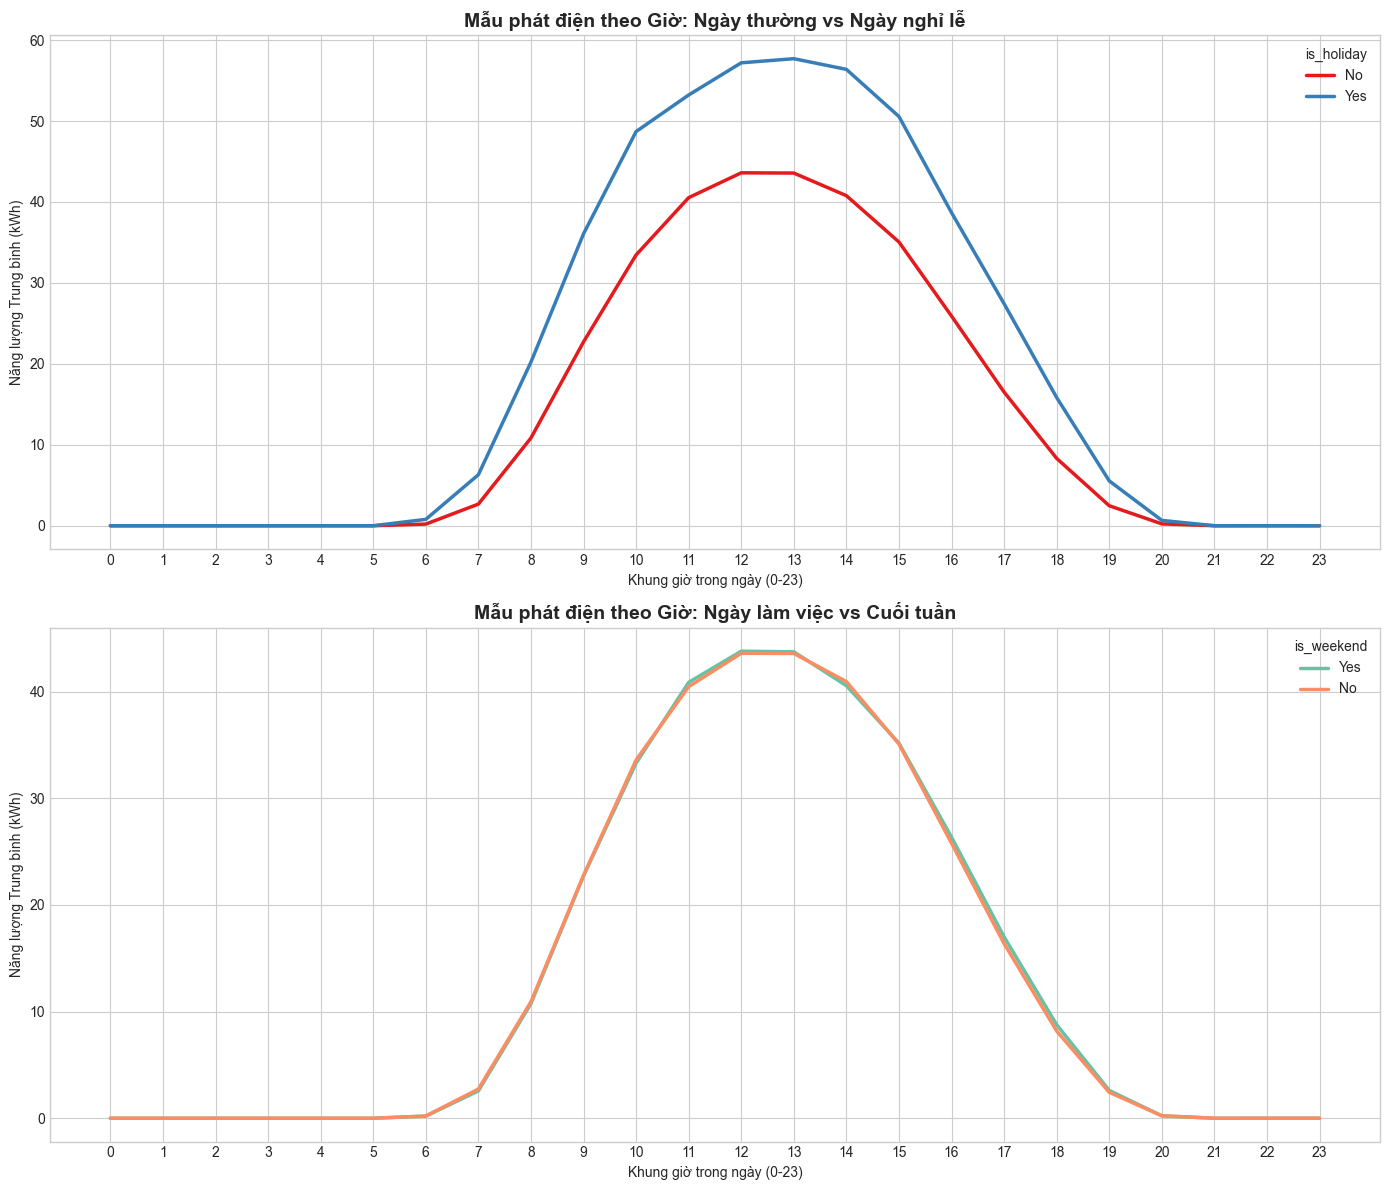

In [4]:
# TRỰC QUAN HÓA TÌM PATTERN NGẦM ĐỊNH
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Biểu đồ 1: Đường cong năng lượng theo Ngày lễ (is_holiday)
sns.lineplot(
    data=df, x='hourly_bucket', y='total_energy', hue='is_holiday', 
    estimator='mean', errorbar=None, ax=axes[0], palette="Set1", linewidth=2.5
)
axes[0].set_title('Mẫu phát điện theo Giờ: Ngày thường vs Ngày nghỉ lễ', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Khung giờ trong ngày (0-23)')
axes[0].set_ylabel('Năng lượng Trung bình (kWh)')
axes[0].set_xticks(range(0, 24))

# Biểu đồ 2: Đường cong năng lượng theo Cuối tuần (is_weekend)
sns.lineplot(
    data=df, x='hourly_bucket', y='total_energy', hue='is_weekend', 
    estimator='mean', errorbar=None, ax=axes[1], palette="Set2", linewidth=2.5
)
axes[1].set_title('Mẫu phát điện theo Giờ: Ngày làm việc vs Cuối tuần', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Khung giờ trong ngày (0-23)')
axes[1].set_ylabel('Năng lượng Trung bình (kWh)')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()


## 4. Phân tích nâng cao: Heatmap Khung giờ Vàng

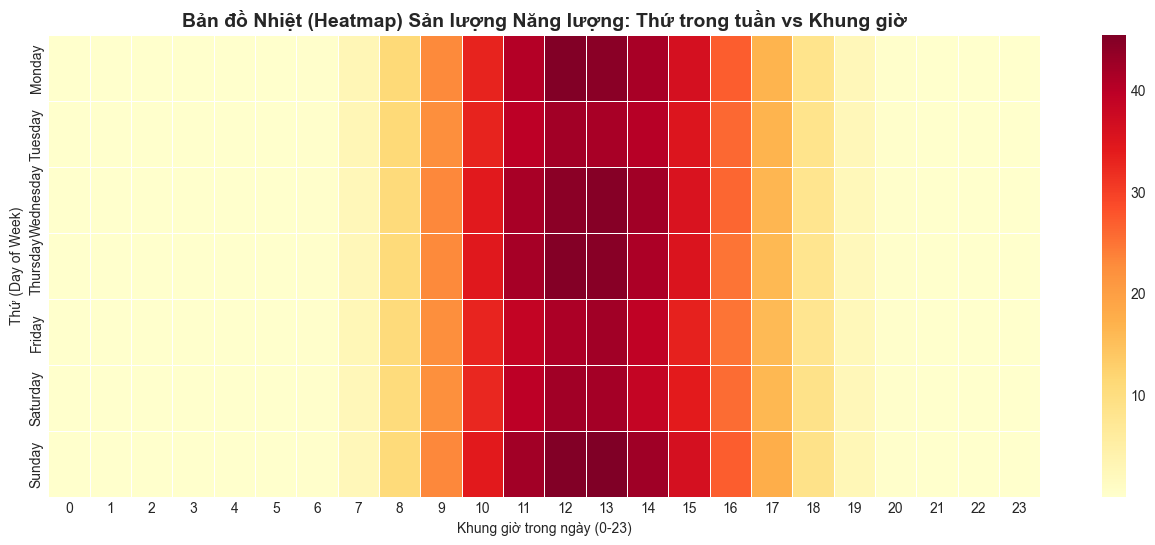

In [5]:
# Heatmap phân phối sản lượng theo Giờ và Thứ (Day of week)
# Sắp xếp thứ tự các ngày trong tuần
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = df.pivot_table(index='day_of_week', columns='hourly_bucket', values='total_energy', aggfunc='mean').fillna(0)
heatmap_data = heatmap_data.reindex(days_order)

plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, fmt=".1f", linewidths=.5)
plt.title('Bản đồ Nhiệt (Heatmap) Sản lượng Năng lượng: Thứ trong tuần vs Khung giờ', fontsize=14, fontweight='bold')
plt.xlabel('Khung giờ trong ngày (0-23)')
plt.ylabel('Thứ (Day of Week)')
plt.show()
